In [1]:
import pickle
import numpy as np
# import casadi as ca
from timeit import default_timer as timer
import matplotlib.pyplot as plt
from pyswarms.single.global_best import GlobalBestPSO
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from util import *
from BayesOpt import *
from BayesOpt_torch import *
from myGP_torch import *
from examples.ex_fcn import *
import warnings
import logging
logging.disable(logging.CRITICAL)

#suppress warnings
warnings.filterwarnings('ignore')

# An example to test contextual Bayesian optimization

In this example, we consider a parametric quadractic function, in which the mapping from contextual variables to solutions of optimization variables is continuous.

$
f(\mathbf{z}, \mathbf{t}) = (z_1 - (2t_1+3t_2))^2 + (z_2 - (4t_1-t_2))^2 + (z_3 - (t_1 t_2))^2
$



In [2]:
class quadratic(blackbox_fcn):
    def __init__(self):
        super().__init__()
        
    def evaluate_true(self, Z, T):
        z1, z2, z3 = Z
        t1, t2 = T
        obj = (z1 - (2*t1+3*t2))**2 + (z2 - (4*t1-t2))**2 + (z3 - (t1*t2))**2
        noise = np.random.normal(0, 0.01)
        return -obj + noise

In [3]:
# Bounds on the inputs variable
n_pts = 101
var_bounds = [(-20., 10.), (-10., 15.), (0., 15.)]
# Bounds on the context variable
ctx_bounds = [(0., 10.), (4., 12.)]
true_fcn = quadratic()
training_params = {"max_iter": 200, "optimizer": "Adam", "num_restarts": 5}
CBO = Context_BayesOpt(3, 2, print_level=True, training_params=training_params)
CBO.set_feasible_set(var_bounds, ctx_bounds, n_pts)

In [4]:
OUTCOME = CBO.run_Outer(true_fcn, k_max = 30, k_init = 10, j_max = 30, j_init = 10, beta = 1e2, beta_rate=0.9, tol=1e-1, patience=3)

Iteration # 1
Sample the context: [5.8 7.6]
Bayes Opt proposes to sample  [ 7.   -5.25  3.6 ]
Bayes Opt proposes to sample  [-4.4   4.75  7.05]
Bayes Opt proposes to sample  [ 7.6  13.75  1.35]
Bayes Opt proposes to sample  [-12.2   14.    12.45]
Bayes Opt proposes to sample  [-7.7  -8.    0.75]
Bayes Opt proposes to sample  [-0.5   8.5   6.75]
Bayes Opt proposes to sample  [-15.5   -5.75  11.1 ]
Bayes Opt proposes to sample  [-17.3   -9.5   12.45]
Bayes Opt proposes to sample  [-8.  -7.   9.6]
Bayes Opt proposes to sample  [-2.6  14.75 12.45]
Bayes Opt proposes to sample  [10. 15. 15.]
Bayes Opt proposes to sample  [-16.48564223  -6.55014677  14.15589136]
Bayes Opt proposes to sample  [10.         15.         10.58858029]
Bayes Opt proposes to sample  [ 10. -10.  15.]
Bayes Opt proposes to sample  [10. 15. 15.]
Bayes Opt proposes to sample  [ 3.35295009  2.61246172 14.31158352]
Bayes Opt proposes to sample  [10. 15. 15.]
Bayes Opt proposes to sample  [10.          6.03346616 15.      

In [8]:
CBO.GP_s.training_params = {"max_iter": 1000, "optimizer": "Adam", "num_restarts": 5}
CBO.GP_s._train_gp(CBO.GP_s.X, CBO.GP_s.Y)

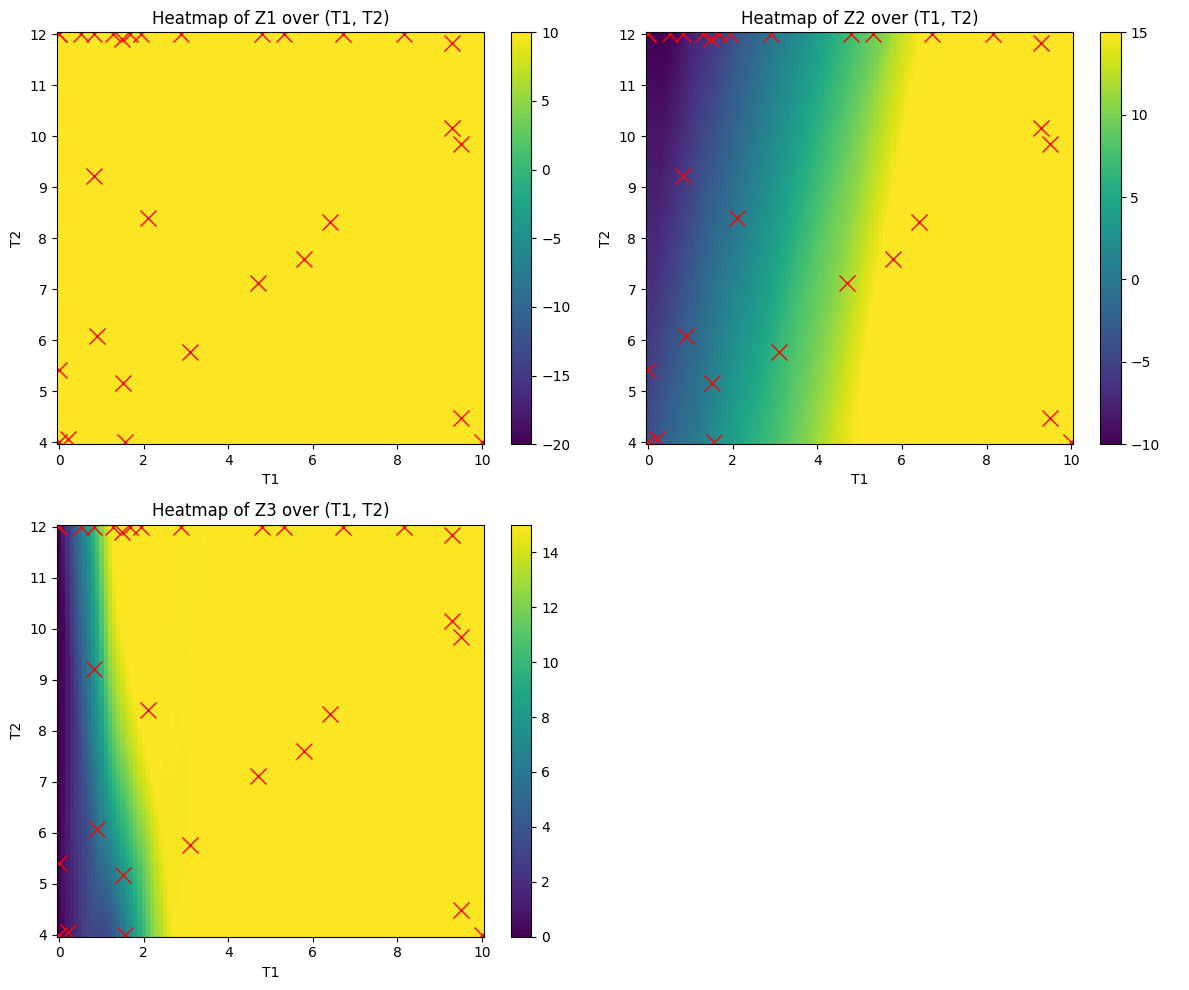

In [9]:
# Separate TT into T1, T2
T1 = CBO.TT[:, 0]
T2 = CBO.TT[:, 1]

Z_GP, _ = CBO.GP_s.predict(CBO.TT)
Z1 = Z_GP[:,0]; Z2 = Z_GP[:,1]; Z3 = Z_GP[:,2]

# Create a figure with two rows and two columns (2x2 grid, but we'll leave the 4th subplot empty)
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Plot the first heatmap (Z1) in the first subplot
c1 = axs[0, 0].pcolormesh(T1.reshape(n_pts, n_pts), T2.reshape(n_pts, n_pts), Z1.reshape(n_pts, n_pts),
                           shading='auto', vmin=var_bounds[0][0], vmax=var_bounds[0][1])
axs[0, 0].set_xlabel('T1')
axs[0, 0].set_ylabel('T2')
axs[0, 0].set_title('Heatmap of Z1 over (T1, T2)')
axs[0, 0].plot(CBO.GP_s.X[:,0].cpu().numpy(), CBO.GP_s.X[:,1].cpu().numpy(), 'rx', markersize = 12)
fig.colorbar(c1, ax=axs[0, 0])

# Plot the second heatmap (Z2) in the second subplot
c2 = axs[0, 1].pcolormesh(T1.reshape(n_pts, n_pts), T2.reshape(n_pts, n_pts), Z2.reshape(n_pts, n_pts),
                           shading='auto', vmin=var_bounds[1][0], vmax=var_bounds[1][1]) 
axs[0, 1].set_xlabel('T1')
axs[0, 1].set_ylabel('T2')
axs[0, 1].set_title('Heatmap of Z2 over (T1, T2)')
axs[0, 1].plot(CBO.GP_s.X[:,0].cpu().numpy(), CBO.GP_s.X[:,1].cpu().numpy(), 'rx', markersize = 12)
fig.colorbar(c2, ax=axs[0, 1])

# Plot the third heatmap (Z3) in the third subplot (first column of the second row)
c3 = axs[1, 0].pcolormesh(T1.reshape(n_pts, n_pts), T2.reshape(n_pts, n_pts), Z3.reshape(n_pts, n_pts),
                           shading='auto', vmin=var_bounds[2][0], vmax=var_bounds[2][1])
axs[1, 0].set_xlabel('T1')
axs[1, 0].set_ylabel('T2')
axs[1, 0].set_title('Heatmap of Z3 over (T1, T2)')
axs[1, 0].plot(CBO.GP_s.X[:,0].cpu().numpy(), CBO.GP_s.X[:,1].cpu().numpy(), 'rx', markersize = 12)
fig.colorbar(c3, ax=axs[1, 0])

# Remove the fourth subplot (2nd column of 2nd row) by turning off its axis
axs[1, 1].axis('off')

# Adjust layout for better spacing between subplots
plt.tight_layout()

# Show the plot
plt.show()


# Ground-truth from a solver

In [10]:
# Using differential evolution and L-BFGS-B optimizer from SciPy
from scipy.optimize import minimize, differential_evolution
sample_T = CBO.TT
best_Zsol = []

for T in sample_T:
    def obj(Z):
        return -true_fcn.evaluate_true(Z, T)
    # First global optimization
    result_de = differential_evolution(obj, var_bounds)
    # Then local refinement
    res = minimize(obj, result_de.x, method='L-BFGS-B', bounds=var_bounds)
    best_Zsol.append(res.x)

best_Zsol = np.array(best_Zsol)

In [11]:
# # Second option: using PSO optimizer

# best_Zsol = []
# sample_T = CBO.TT

# # instatiate the optimizer
# x_max = CBO.ZZ[-1]
# x_min = CBO.ZZ[0]
# bounds = (x_min, x_max)
# options = {'c1': 0.5, 'c2': 0.3, 'w': 0.9}

# for T in sample_T:
#     # Define objective function for given T
#     def objective(Z_particles):
#         # By default, PSO minimize the function, so need - sign here
#         return -np.array([true_fcn.evaluate_true(Z, T) for Z in Z_particles])
    
#     optimizer = GlobalBestPSO(n_particles=20, dimensions=2, options=options, bounds=bounds)
#     # Optimize
#     cost, pos = optimizer.optimize(objective, iters=100, verbose=False)
#     best_Zsol.append(pos)

# best_Zsol = np.array(best_Zsol)


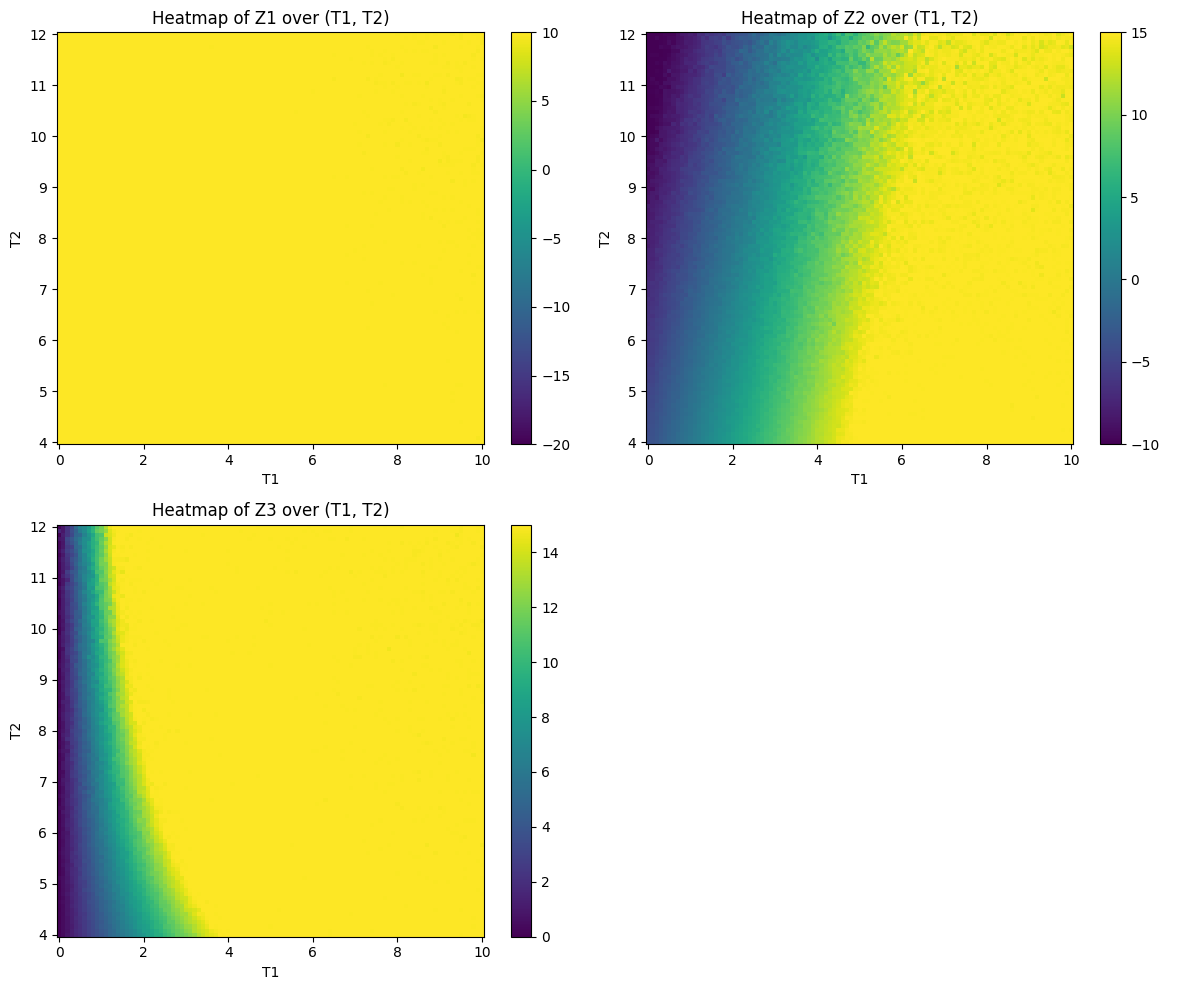

In [12]:
# Separate TT into T1, T2
T1 = sample_T[:, 0]
T2 = sample_T[:, 1]

# Separate Z into Z1, Z2, Z3
Z1 = best_Zsol[:, 0]
Z2 = best_Zsol[:, 1]
Z3 = best_Zsol[:, 2]

# Create a figure with two rows and two columns (2x2 grid, but we'll leave the 4th subplot empty)
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Plot the first heatmap (Z1) in the first subplot
c1 = axs[0, 0].pcolormesh(T1.reshape(n_pts, n_pts), T2.reshape(n_pts, n_pts), Z1.reshape(n_pts, n_pts),
                           shading='auto', vmin=var_bounds[0][0], vmax=var_bounds[0][1])
axs[0, 0].set_xlabel('T1')
axs[0, 0].set_ylabel('T2')
axs[0, 0].set_title('Heatmap of Z1 over (T1, T2)')
fig.colorbar(c1, ax=axs[0, 0])

# Plot the second heatmap (Z2) in the second subplot
c2 = axs[0, 1].pcolormesh(T1.reshape(n_pts, n_pts), T2.reshape(n_pts, n_pts), Z2.reshape(n_pts, n_pts),
                           shading='auto', vmin=var_bounds[1][0], vmax=var_bounds[1][1]) 
axs[0, 1].set_xlabel('T1')
axs[0, 1].set_ylabel('T2')
axs[0, 1].set_title('Heatmap of Z2 over (T1, T2)')
fig.colorbar(c2, ax=axs[0, 1])

# Plot the third heatmap (Z3) in the third subplot (first column of the second row)
c3 = axs[1, 0].pcolormesh(T1.reshape(n_pts, n_pts), T2.reshape(n_pts, n_pts), Z3.reshape(n_pts, n_pts),
                           shading='auto', vmin=var_bounds[2][0], vmax=var_bounds[2][1])
axs[1, 0].set_xlabel('T1')
axs[1, 0].set_ylabel('T2')
axs[1, 0].set_title('Heatmap of Z3 over (T1, T2)')
fig.colorbar(c3, ax=axs[1, 0])

# Remove the fourth subplot (2nd column of 2nd row) by turning off its axis
axs[1, 1].axis('off')

# Adjust layout for better spacing between subplots
plt.tight_layout()

# Show the plot
plt.show()
